In [2]:
%load_ext dotenv
%dotenv 
import os
import sys
sys.path.append(os.getenv('SRC_DIR'))
from logger import get_logger
_logs = get_logger(__name__)

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [3]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import os
from glob import glob

c:\Users\Kavoshgaran\miniconda3\envs\dsi_participant\lib\site-packages\dask\dataframe\_pyarrow_compat.py:15: FutureWarning: Minimal version of pyarrow will soon be increased to 14.0.1. You are using 11.0.0. Please consider upgrading.
  warnings.warn(


In [6]:
ft_dir = os.getenv("FEATURES_DATA")
ft_dir

'../../05_src/data/features/stock_features.parquet'

In [7]:
ft_dir = os.path.join(os.path.dirname(os.getenv("FEATURES_DATA")), "stock_features")

In [8]:
print(ft_dir)

../../05_src/data/features\stock_features


In [9]:
ft_glob=glob(os.path.join(ft_dir,"**/*.parquet"),recursive=True)

In [11]:
ft_glob

['../../05_src/data/features\\stock_features\\part.0.parquet',
 '../../05_src/data/features\\stock_features\\part.1.parquet',
 '../../05_src/data/features\\stock_features\\part.10.parquet',
 '../../05_src/data/features\\stock_features\\part.100.parquet',
 '../../05_src/data/features\\stock_features\\part.1000.parquet',
 '../../05_src/data/features\\stock_features\\part.10000.parquet',
 '../../05_src/data/features\\stock_features\\part.10001.parquet',
 '../../05_src/data/features\\stock_features\\part.10002.parquet',
 '../../05_src/data/features\\stock_features\\part.10003.parquet',
 '../../05_src/data/features\\stock_features\\part.10004.parquet',
 '../../05_src/data/features\\stock_features\\part.10005.parquet',
 '../../05_src/data/features\\stock_features\\part.10006.parquet',
 '../../05_src/data/features\\stock_features\\part.10007.parquet',
 '../../05_src/data/features\\stock_features\\part.10008.parquet',
 '../../05_src/data/features\\stock_features\\part.10009.parquet',
 '../../0

In [12]:
df=dd.read_parquet(ft_glob).compute().reset_index()

In [13]:
df

Price,Ticker,Date,Adj Close,Close,High,Low,Open,Volume,Year,Close_lag_1
0,DOV,2005-01-03 00:00:00+00:00,18.734230,27.604422,28.227835,27.544090,28.107174,762305.0,2005,NaN
1,DOV,2005-01-04 00:00:00+00:00,18.647789,27.477058,28.013327,27.403320,27.865852,1330378.0,2005,27.604422
2,DOV,2005-01-05 00:00:00+00:00,18.283836,26.940788,27.785412,26.907272,27.477058,1176575.0,2005,27.477058
3,DOV,2005-01-06 00:00:00+00:00,18.110960,26.686062,26.981009,26.625732,26.981009,1395122.0,2005,26.940788
4,DOV,2005-01-07 00:00:00+00:00,17.847103,26.297268,26.726282,26.277157,26.625732,1192984.0,2005,26.686062
...,...,...,...,...,...,...,...,...,...,...
3173422,CTLT,2009-12-24 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,2009,NaN
3173423,CTLT,2009-12-28 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,2009,NaN
3173424,CTLT,2009-12-29 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,2009,NaN
3173425,CTLT,2009-12-30 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,2009,NaN


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3173427 entries, 0 to 3173426
Data columns (total 10 columns):
 #   Column       Dtype              
---  ------       -----              
 0   Ticker       object             
 1   Date         datetime64[ns, UTC]
 2   Adj Close    float64            
 3   Close        float64            
 4   High         float64            
 5   Low          float64            
 6   Open         float64            
 7   Volume       float64            
 8   Year         int32              
 9   Close_lag_1  float64            
dtypes: datetime64[ns, UTC](1), float64(7), int32(1), object(1)
memory usage: 230.0+ MB


In [18]:
df["Ticker"].unique()

array(['DOV', 'CBRE', 'FANG', 'DTE', 'AOS', 'BDX', 'BA', 'KEY', 'BXP',
       'INCY', 'ORLY', 'BRO', 'CTVA', 'MCO', 'REG', 'FITB', 'RTX', 'FSLR',
       'HAS', 'ZBH', 'HWM', 'RL', 'APA', 'HSY', 'LDOS', 'MRNA', 'ECL',
       'BF.B', 'FLT', 'PFE', 'BIIB', 'FOXA', 'PNW', 'STZ', 'INTU', 'AEE',
       'SNPS', 'GWW', 'LH', 'IBM', 'TFX', 'CCL', 'WM', 'VZ', 'DFS', 'FDX',
       'VRSK', 'UHS', 'PARA', 'XEL', 'FOX', 'ZTS', 'CTSH', 'AAL', 'AIG',
       'BR', 'EL', 'JNJ', 'LIN', 'EQR', 'MTCH', 'EOG', 'CCI', 'WST',
       'HAL', 'MOH', 'NKE', 'KMB', 'TDY', 'TMUS', 'KLAC', 'MSCI', 'TAP',
       'GPN', 'MCK', 'AES', 'JCI', 'TDG', 'VLO', 'CAH', 'GM', 'ED', 'SNA',
       'DOW', 'CMA', 'TRMB', 'DE', 'GE', 'LHX', 'META', 'CEG', 'AMP',
       'MCHP', 'AEP', 'KMI', 'TSN', 'PEAK', 'UNH', 'TRGP', 'IDXX', 'PFG',
       'MOS', 'GRMN', 'IFF', 'MO', 'ETSY', 'HSIC', 'AME', 'IQV', 'INVH',
       'MRK', 'EW', 'PM', 'ANSS', 'ABBV', 'TROW', 'EXPD', 'MAA', 'D',
       'PSA', 'CRM', 'EG', 'XRAY', 'WFC', 'MHK', 'KEYS', 

# Sampling in Python

+ There are different packages that allow sampling.
+ A practical approach is to use pandas/Dask sampling methods.

## Random Sampling

+ Sample n rows from a dataframe with [`df.sample()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html).

```
DataFrame.sample(
    n=None, frac=None, replace=False, weights=None, 
    random_state=None, axis=None, ignore_index=False
    )
```

In [19]:
df.sample(n = 5,random_state=42)

Price,Ticker,Date,Adj Close,Close,High,Low,Open,Volume,Year,Close_lag_1
1983097,FTNT,2002-04-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,2002,NaN
2150583,COST,2005-11-17 00:00:00+00:00,34.029400,49.820000,49.840000,49.110001,49.259998,2426600.0,2005,49.200001
239734,GWW,2025-01-22 00:00:00+00:00,1122.930054,1122.930054,1128.660034,1117.010010,1122.000000,308300.0,2025,1121.510010
941975,C,2001-09-07 00:00:00+00:00,237.748138,434.200012,440.000000,425.000000,431.000000,1730730.0,2001,440.500000
971794,PCG,2010-10-29 00:00:00+00:00,36.520802,47.820000,47.919998,47.279999,47.630001,2042300.0,2010,47.730000


In [20]:
# select_tickers = df['ticker'].unique().tolist()[0:9]
select_tickers = ['OXY', 'TXN', 'PCG', 'CBRE', 'ROK', 'AMT', 'D', 'YUM', 'PWR']
select_tickers

['OXY', 'TXN', 'PCG', 'CBRE', 'ROK', 'AMT', 'D', 'YUM', 'PWR']

In [25]:
idx = df['Ticker'].isin(select_tickers)
small_df = df[idx]
simple_sample_dt = small_df.sample(frac = 0.1)
simple_sample_dt.shape, small_df.shape



((5678, 10), (56781, 10))

Look at the distribution of tickers.

<Axes: xlabel='Ticker'>

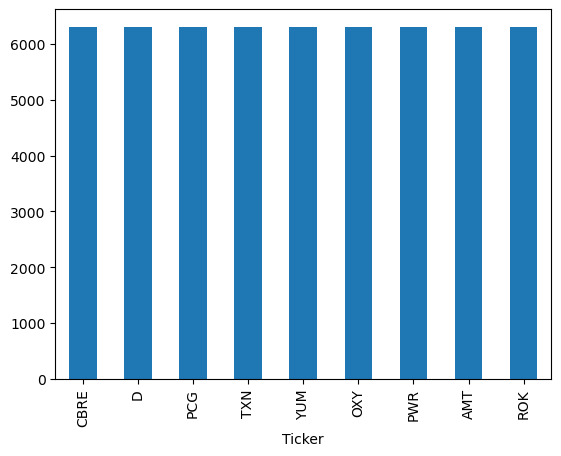

In [29]:
small_df['Ticker'].value_counts().plot(kind='bar')

<Axes: xlabel='Ticker'>

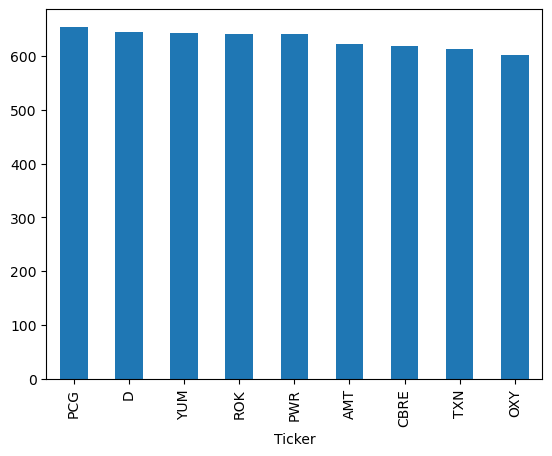

In [30]:
simple_sample_dt['Ticker'].value_counts().plot(kind='bar')

## Stratified Sampling

+ Use `groupby()` and `.sample()` for stratified sampling.

<Axes: xlabel='Ticker'>

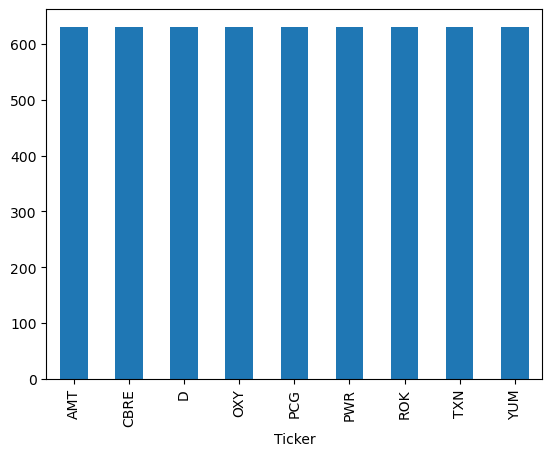

In [32]:
strat_sample_dt = small_df.groupby(['Ticker']).sample(frac = 0.1)
strat_sample_dt['Ticker'].value_counts().plot(kind='bar')

# Sampling in Dask

+ Stratified sampling in `dask` can be achieved with `groupby().apply()` and a lambda function.

C:\Users\Kavoshgaran\AppData\Local\Temp\ipykernel_9680\2388710987.py:2: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  strat_sample_dd_dt = (dd_dt


c:\Users\Kavoshgaran\miniconda3\envs\dsi_participant\lib\site-packages\pyarrow\pandas_compat.py:766: DeprecationWarning: DatetimeTZBlock is deprecated and will be removed in a future version. Use public APIs instead.
  klass=_int.DatetimeTZBlock,
c:\Users\Kavoshgaran\miniconda3\envs\dsi_participant\lib\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to DataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(


<Axes: xlabel='Ticker'>

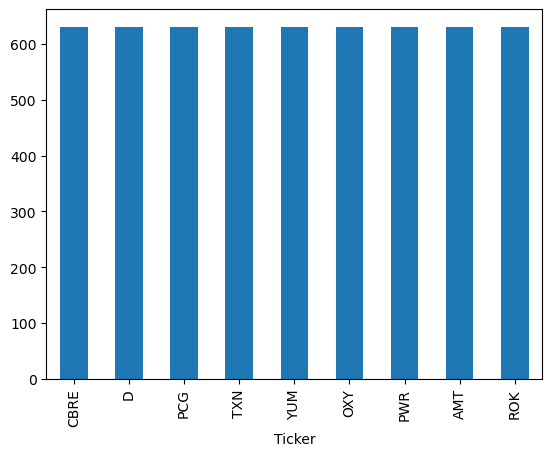

In [34]:
dd_dt = dd.read_parquet(ft_glob)
strat_sample_dd_dt = (dd_dt
                      .groupby('Ticker', group_keys=False)
                      .apply(lambda x: x.sample(frac = 0.1))
                      .compute()
                      .reset_index())
strat_sample_dd_dt[strat_sample_dd_dt['Ticker'].isin(select_tickers)]['Ticker'].value_counts().plot(kind='bar')